# Uniqueness of equilibrium? 

Consider Kehoe's example with a CES function:

$$
u_i = a_1^i(x_1^{b_i}-1)/b_i + a_2^i(x_2^{b_i}-1)/b_i
$$

Let $\eta_i = 1/(1-b_i)$. 

This gives demand functions (demand for good $j$ by consumer $i$):

$$
x_j^i(p_1,p_2) = \frac{(a_j^i)^{\eta_i}(p_1w^i_1+p_2w_2^i)}{p_j^{\eta_i}((a_1^i)^{\eta_i}p_1^{1-\eta_i}+(a_2^i)^{\eta_i}p_2^{1-\eta_i})}
$$

Kehoe shows there are multiple equilibria for the case in which we have: $b_1=b_2=-4$, so $\eta_1=\eta_2=.2$. Also, $a_1^1=a_2^2=1024$, while $a_2^1=a_1^2=1$, and $w_1^1=w_2^2=60$, and $w_1^2=w_2^1=5$. Let's just write up a routine and see how this goes...


Let's think about the demand for good 1, and adopt the normalization that $p_1+p_2=1$. Then:

$$
x_1^i(p_1,p_2) = \frac{(a_1^i)^{\eta_i}(p_1w^i_1+(1-p_1)w_2^i)}{p_1^{\eta_i}((a_1^i)^{\eta_i}p_1^{1-\eta_i}+(a_2^i)^{\eta_i}(1-p_1)^{1-\eta_i})}
$$

Now, according to Walras's law, we can think about everything in terms of this function.  So, let's actually do a little programming to get this all straight. We have:

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
def d1(p1, a1, a2, w1, w2, eta=.2):
    
    p2 = 1 - p1
    num = a1**eta*(p1*w1 + p2*w2)
    den = p1**eta*(a1**eta*p1**(1-eta) + a2**eta*p2**(1-eta))
    
    return num / den
    
def z1(p1, a11, a12, a21, a22, w11, w12, w21, w22, eta1, eta2):
    
    x1 = d1(p1, a11, a12, w11, w12, eta1)
    x2 = d1(p1, a21, a22, w21, w22, eta2)
    
    return x1 + x2 - w11 - w12
    

In [6]:
# Kehoe's example:

A11 = 1024
A12 = 5
A21 = 5
A22 = 1024
W11 = 60
W12 = 5
W21 = 5
W22 = 60
ET1 = .2
ET2 = .2

pr = np.arange(0.05,.99,.01)

zr = z1(pr, A11, A12, A21, A22, W11, W12, W21, W22, ET1, ET2)
x1r = d1(pr, A11, A12, W11, W12, ET1)
x2r = d1(pr, A21, A22, W21, W22, ET2)

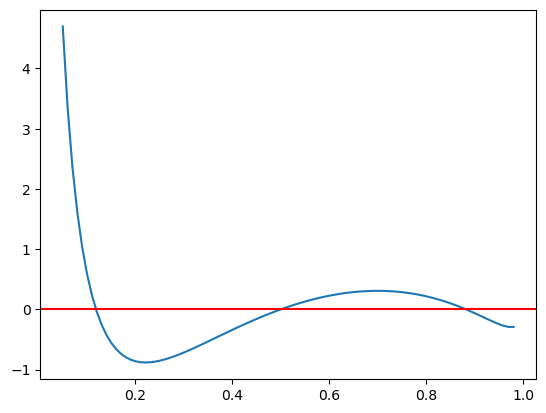

In [7]:
plt.plot(pr, zr)
plt.axhline(0, color='red')

# Illustration of how demands change as prices increase



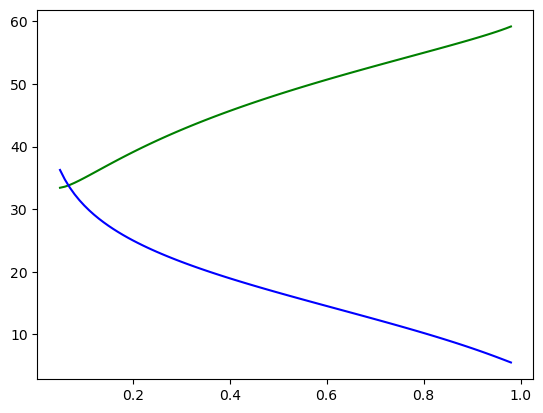

In [9]:
plt.plot(pr, x1r, color='green')
plt.plot(pr, x2r, color='blue')